In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pointbiserialr

sns.set_style("whitegrid")

features = pd.read_csv("../data/processed/features.csv")
labels = pd.read_csv("../data/processed/labels.csv")
metadata = pd.read_csv("../data/processed/feature_metadata.csv")

df = features.merge(
    labels[
        [
            "customer_id",
            "label_channel",
            "label_score",
            "low_confidence"
        ]
    ],
    on="customer_id"
)

print(df.shape)

numeric_features = metadata.loc[
    metadata["is_categorical"] == False,
    "feature_name"
].tolist()

numeric_features = [
    c for c in numeric_features
    if c in df.columns
]

(28297, 144)


# 02 — Feature Exploration
## Channel Affinity Prediction System

This notebook examines the engineered feature table used to predict a customer's preferred communication channel.

The objective is to understand:

- Feature sparsity
- Channel-specific behavioural signals
- Feature separation across affinity labels
- Correlation structure
- Rule-based signal quality

These insights will guide both the rule-based baseline and the machine learning model.

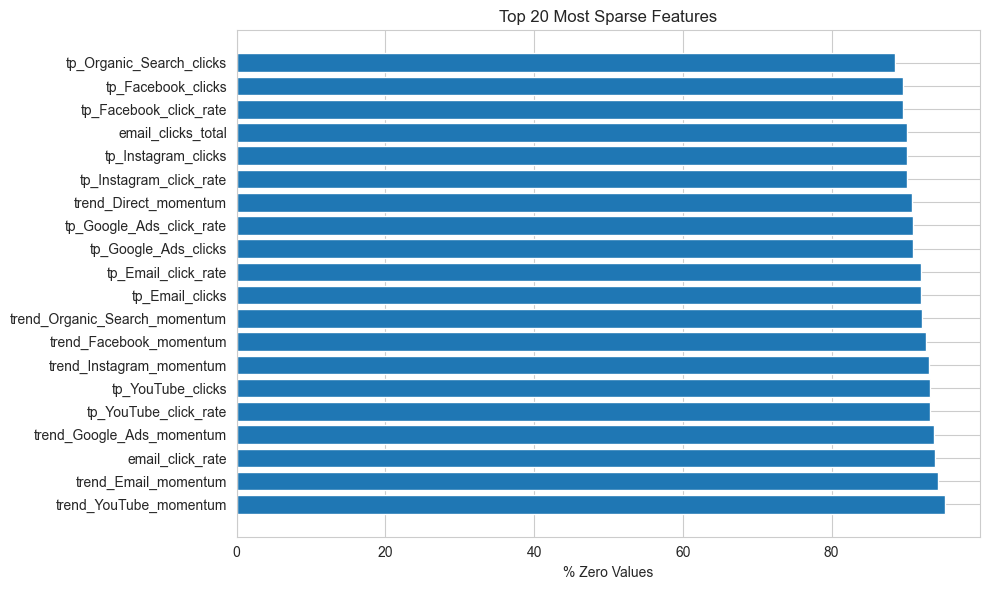

,feature,sparsity_pct
48,trend_YouTube_momentum,95.190303
12,trend_Email_momentum,94.289147
85,email_click_rate,93.854472
30,trend_Google_Ads_momentum,93.766124
47,tp_YouTube_click_rate,93.193625


In [2]:
## 1. Feature Sparsity

sparsity = pd.DataFrame({
    "feature": numeric_features,
    "sparsity_pct": [
        (df[col] == 0).mean() * 100
        for col in numeric_features
    ]
})

sparsity = sparsity.sort_values(
    "sparsity_pct",
    ascending=False
)

top_sparse = sparsity.head(20)

plt.figure(figsize=(10,6))

plt.barh(
    top_sparse["feature"],
    top_sparse["sparsity_pct"]
)

plt.xlabel("% Zero Values")
plt.title("Top 20 Most Sparse Features")

plt.tight_layout()

plt.savefig(
    "../reports/05_sparsity.png",
    bbox_inches="tight"
)

plt.show()

sparsity.head()

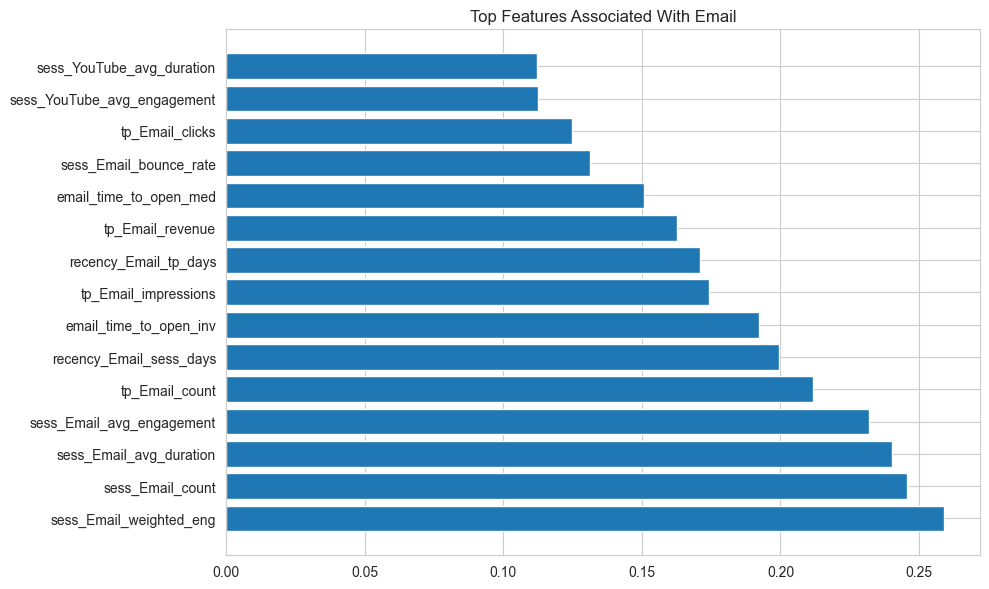

,feature,correlation
53,sess_Email_weighted_eng,0.259017
49,sess_Email_count,0.245711
51,sess_Email_avg_duration,0.240392
50,sess_Email_avg_engagement,0.231772
7,tp_Email_count,0.211598
109,recency_Email_sess_days,0.199440
89,email_time_to_open_inv,0.192083
9,tp_Email_impressions,0.174225
108,recency_Email_tp_days,0.170901
10,tp_Email_revenue,0.162661


In [3]:
## 2. Discriminative Features by Channel
channel = "Email"

temp = df.copy()

temp["target"] = (
    temp["label_channel"] == channel
).astype(int)

results = []

for col in numeric_features:

    try:

        corr, _ = pointbiserialr(
            temp["target"],
            temp[col]
        )

        results.append(
            [col, abs(corr)]
        )

    except:
        pass

corr_df = pd.DataFrame(
    results,
    columns=[
        "feature",
        "correlation"
    ]
)

corr_df = corr_df.sort_values(
    "correlation",
    ascending=False
)

top = corr_df.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top["feature"],
    top["correlation"]
)

plt.title(
    f"Top Features Associated With {channel}"
)

plt.tight_layout()

plt.savefig(
    "../reports/06_discriminative_features.png",
    bbox_inches="tight"
)

plt.show()

top

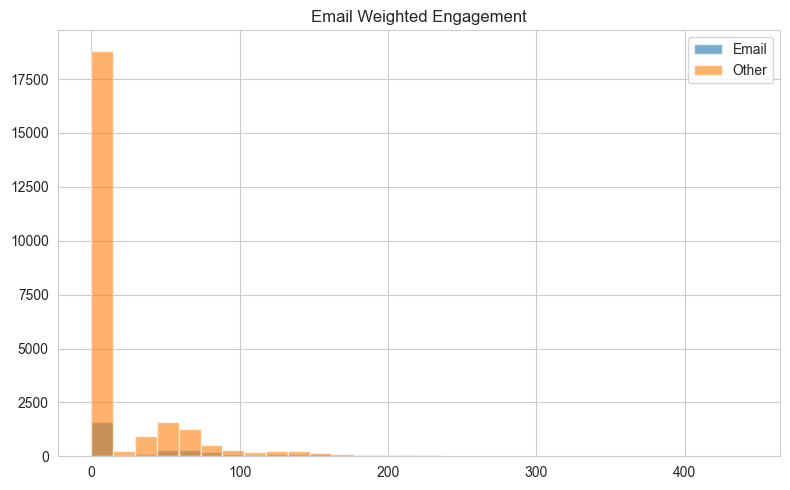

In [4]:
## 3. Feature Distributions for Preferred vs Non-Preferred Customers
feature = "sess_Email_weighted_eng"

preferred = df.loc[
    df["label_channel"] == "Email",
    feature
]

other = df.loc[
    df["label_channel"] != "Email",
    feature
]

plt.figure(figsize=(8,5))

plt.hist(
    preferred,
    bins=30,
    alpha=0.6,
    label="Email"
)

plt.hist(
    other,
    bins=30,
    alpha=0.6,
    label="Other"
)

plt.legend()

plt.title(
    "Email Weighted Engagement"
)

plt.tight_layout()

plt.savefig(
    "../reports/07_feature_distributions.png",
    bbox_inches="tight"
)

plt.show()

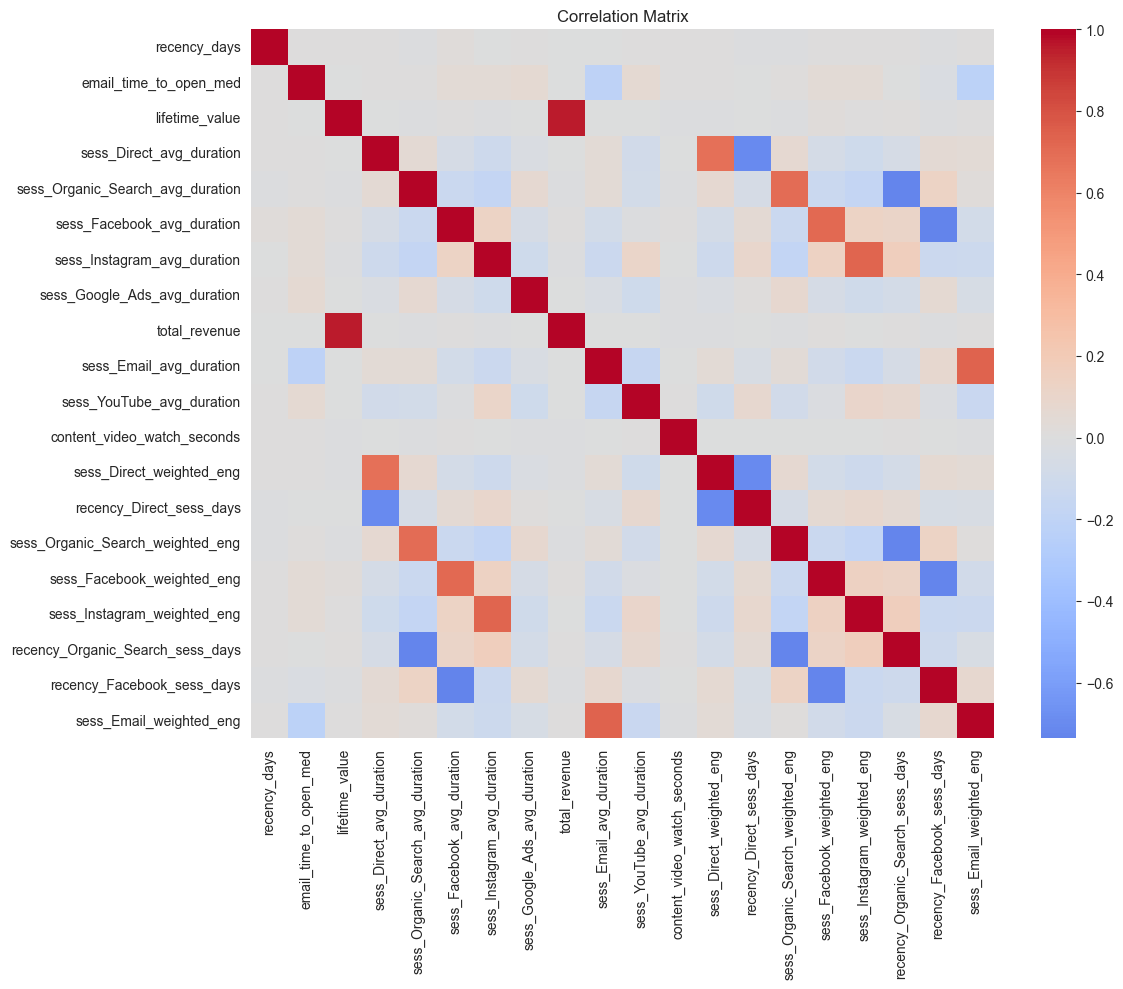

In [5]:
## 4. Correlation Structure

variance_features = (
    df[numeric_features]
    .var()
    .sort_values(ascending=False)
    .head(20)
    .index
)

corr = (
    df[variance_features]
    .corr()
)

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Matrix"
)

plt.tight_layout()

plt.savefig(
    "../reports/08_correlation_matrix.png",
    bbox_inches="tight"
)

plt.show()

In [6]:
## 5. Signal Strength Assessment
CHANNEL_SIGNALS = {
    "Email": "email_click_rate",
    "Facebook": "social_Facebook_count",
    "Instagram": "social_Instagram_count",
    "Google Ads": "tp_Google_Ads_click_rate",
    "Organic Search": "tp_Organic_Search_count",
    "Direct": "tp_Direct_count",
    "YouTube": "content_video_watch_seconds"
}

results = []

for channel, signal in CHANNEL_SIGNALS.items():

    preferred = (
        df.loc[
            df["label_channel"] == channel,
            signal
        ]
        .mean()
    )

    other = (
        df.loc[
            df["label_channel"] != channel,
            signal
        ]
        .mean()
    )

    results.append([
        channel,
        signal,
        preferred,
        other,
        preferred / max(other, 0.0001)
    ])

signal_df = pd.DataFrame(
    results,
    columns=[
        "channel",
        "signal",
        "preferred_mean",
        "other_mean",
        "lift"
    ]
)

signal_df

,channel,signal,preferred_mean,other_mean,lift
0,Email,email_click_rate,0.105506,0.070791,1.490390
1,Facebook,social_Facebook_count,0.201807,0.212251,0.950794
2,Instagram,social_Instagram_count,0.209609,0.213015,0.984012
3,Google Ads,tp_Google_Ads_click_rate,0.110153,0.070615,1.559908
4,Organic Search,tp_Organic_Search_count,0.680663,0.401640,1.694708
5,Direct,tp_Direct_count,0.633932,0.490254,1.293068
6,YouTube,content_video_watch_seconds,142.670487,139.975181,1.019256


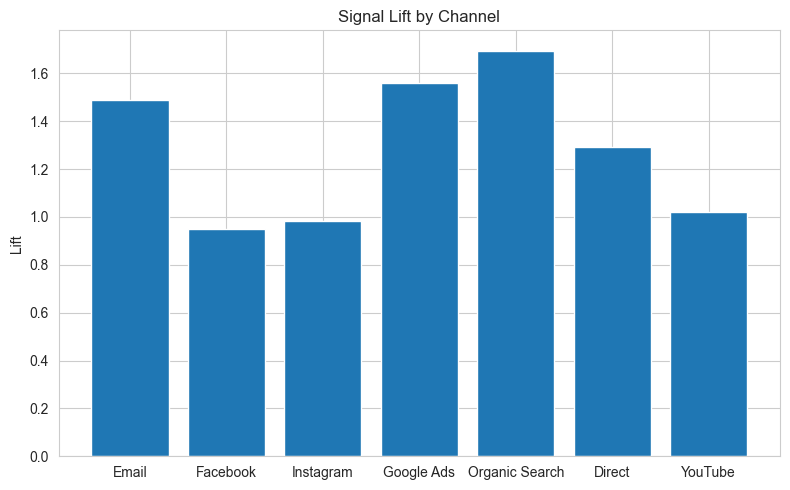

In [7]:
plt.figure(figsize=(8,5))

plt.bar(
    signal_df["channel"],
    signal_df["lift"]
)

plt.ylabel("Lift")
plt.title("Signal Lift by Channel")

plt.tight_layout()

plt.savefig(
    "../reports/09_signal_lift.png",
    bbox_inches="tight"
)

plt.show()

## Key Findings

### Feature Sparsity

A large proportion of channel-specific features are sparse, particularly trend and click-related metrics. This is expected because most customers interact with only a subset of available channels. The sparsity pattern reflects realistic customer behavior rather than data quality issues.

### Channel-Specific Signals

The strongest features associated with Email affinity are primarily email engagement and session-based metrics, including weighted engagement, session count, average duration, and recent activity. This indicates that historical interaction behavior contains meaningful information about future channel preference.

### Feature Separation

Distribution analysis shows that customers labeled for a specific channel generally exhibit stronger engagement within that channel than the broader customer population. However, substantial overlap remains between groups, suggesting that channel affinity prediction is a realistic classification problem rather than a simple rule-matching exercise.

### Correlation Structure

Several related feature families exhibit moderate positive correlation, particularly engagement and activity metrics within the same channel. At the same time, most feature groups provide complementary information, indicating that the feature set captures multiple dimensions of customer behavior.

### Signal Strength Assessment

The behavioral signals used in the label construction process demonstrate measurable lift across most channels. Organic Search, Google Ads, and Email show the strongest separation, while Facebook and Instagram display weaker but still meaningful differentiation. This suggests that some channels will be easier to predict than others.

### Implications for Modeling

The feature table contains a mix of customer profile, engagement, recency, trend, and channel-specific behavioral signals. Together, these features provide a strong foundation for both an interpretable rule-based affinity model and a machine learning approach such as LightGBM.

### Next Step

The next stage is to build a rule-based affinity scorer and compare its performance against a machine learning model to determine how effectively future channel preference can be predicted from historical customer behavior.